# ResNet50 - Post Training Analysis

Intended to be ran following training; training can be performed using train_model.py, with tuning.py used as determining hyperparameters for config.py

In [1]:
import cv2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torchvision import models
import torch.nn as nn
import torchvision.transforms.functional as F
from torch.amp import autocast, GradScaler

from tqdm.notebook import tqdm
from PIL import Image

from data_loader import NIH8Dataset, train_data_transforms, val_data_transforms
from utils import *
from config import *

In [2]:
# Configurations

# Paths, Directories
print(f"CSV Path:       {CSV_PATH}")
print(f"Image Folders:  {IMAGE_FOLDERS}")
print(f"Checkpoint:     {MODEL_SAVE_PATH}")

# Get device
device = get_device()
print(f"Device:         {device}")

CSV Path:       d:\DSC Downloads\NIH-XRay-Segmentation\data\Data_Entry_2017.csv
Image Folders:  [WindowsPath('d:/DSC Downloads/NIH-XRay-Segmentation/images')]
Checkpoint:     checkpoints/best_resnet50_nih_512.pt
Device:         cuda


In [3]:
# Patient-wise split
print("1. Loading CSV and Splitting by Patient...")
df = pd.read_csv(CSV_PATH)
train_df, val_df, test_df = get_train_val_test_split(df, TRAIN_SPLIT, VAL_SPLIT)

# Image folders 
folders = [str(IMAGE_FOLDERS[0] / f"images_{str(i).zfill(3)}") for i in range(1, 13)]


print("\n2. Initializing Train and Validation Datasets")
train_ds = NIH8Dataset(train_df, folders, subset_size=TRAIN_SUBSET_SIZE, transform=train_data_transforms, cache_path=CACHE_PATH)
val_ds   = NIH8Dataset(val_df,   folders, subset_size=VAL_SUBSET_SIZE, transform=val_data_transforms, cache_path=CACHE_PATH)
test_ds  = NIH8Dataset(test_df,  folders, subset_size=VAL_SUBSET_SIZE, transform=val_data_transforms, cache_path=CACHE_PATH)

# train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS, pin_memory=True)

num_classes = len(train_ds.classes)
classes = train_ds.classes
print(f"\nDataset initialization complete!")
print(f"  Class Count: {num_classes}")
print(f"  Classes:     {classes}")

1. Loading CSV and Splitting by Patient...
[Utils] Performing Train/Val/Test split with proportions: Train=0.7, Val=0.15, Test=0.15000000000000005
    [Utils] Train-Val-Test Split Complete: 
    Train   ---> Images: 78299 | Unique Patients: 21563 | Num. Classes: 726
    Val     ---> Images: 17097 | Unique Patients: 4621 | Num. Classes: 373
    Test    ---> Images: 16724 | Unique Patients: 4621 | Num. Classes: 385

2. Initializing Train and Validation Datasets
[Dataset] Found 15 unique pathologies: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
[Dataset] Loading image paths from cache: path_cache.json

DATASET SUMMARY
Total images:     78,299
Unique patients:  21,563
Pathologies:      15

[Dataset] Found 15 unique pathologies: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'I

In [4]:
# Model Initialization, using ResNet50 
print("\n3. Initializing Model...")
model = models.resnet50(weights=None) # Checkpoint has weights
model.fc = nn.Linear(model.fc.in_features, num_classes) # Replace final layer for NIH finding classes
model = model.to(device)

checkpoint = torch.load(MODEL_SAVE_PATH, weights_only=False)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

print(f"Loaded checkpoint from Epoch {checkpoint['epoch']+1}")
print(f"Best Val AUC: {checkpoint['best_auc']:.4f}")


3. Initializing Model...
Loaded checkpoint from Epoch 3
Best Val AUC: 0.8138


In [5]:
print("\n4. Running Inference on Test Set...")
all_labels_list = []
all_probs_list  = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Running inference on test set"):
        if batch is None:
            continue
        x = batch["image"].to(device, non_blocking=True)
        y = batch["labels"]

        probs = torch.sigmoid(model(x))
        all_labels_list.append(y.cpu().numpy())
        all_probs_list.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels_list, axis=0)
all_probs  = np.concatenate(all_probs_list,  axis=0)

print(f"\nTest set: {all_labels.shape[0]:,} images | {num_classes} classes")


4. Running Inference on Test Set...


Running inference on test set:   0%|          | 0/523 [00:00<?, ?it/s]


Test set: 16,724 images | 15 classes


In [6]:
print("\n5. Calculating Metrics on Test Set...")
test_metrics = calculate_metrics(all_labels, all_probs, threshold=0.5)
print_metrics(test_metrics, classes)


5. Calculating Metrics on Test Set...
Class                            AUC    Precision     Recall         F1
------------------------------------------------------------------------------------------
Atelectasis                   0.7882       0.2311     0.6807     0.3451
Cardiomegaly                  0.8887       0.1690     0.6009     0.2638
Consolidation                 0.7988       0.1261     0.5882     0.2077
Edema                         0.8917       0.1567     0.5345     0.2423
Effusion                      0.8675       0.3344     0.7917     0.4702
Emphysema                     0.9306       0.3263     0.6643     0.4376
Fibrosis                      0.7972       0.1253     0.1708     0.1446
Hernia                        0.9118       0.4000     0.0465     0.0833
Infiltration                  0.6879       0.2703     0.6039     0.3734
Mass                          0.7995       0.2051     0.4946     0.2899
No Finding                    0.7623       0.7219     0.7367     0.7292
Nodule

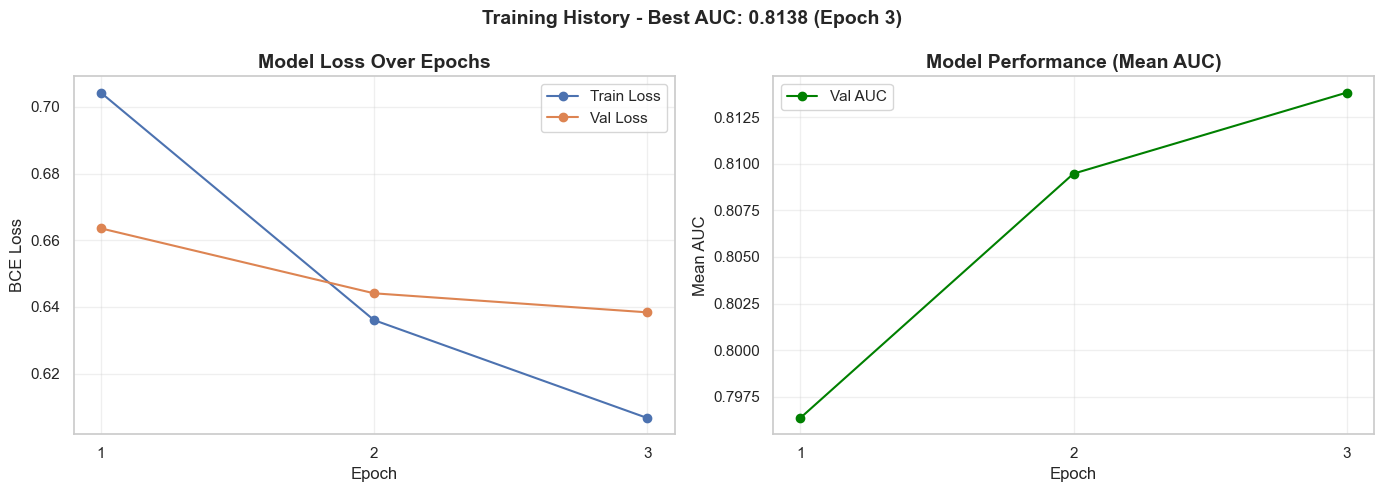

In [7]:
plot_training_history(checkpoint)

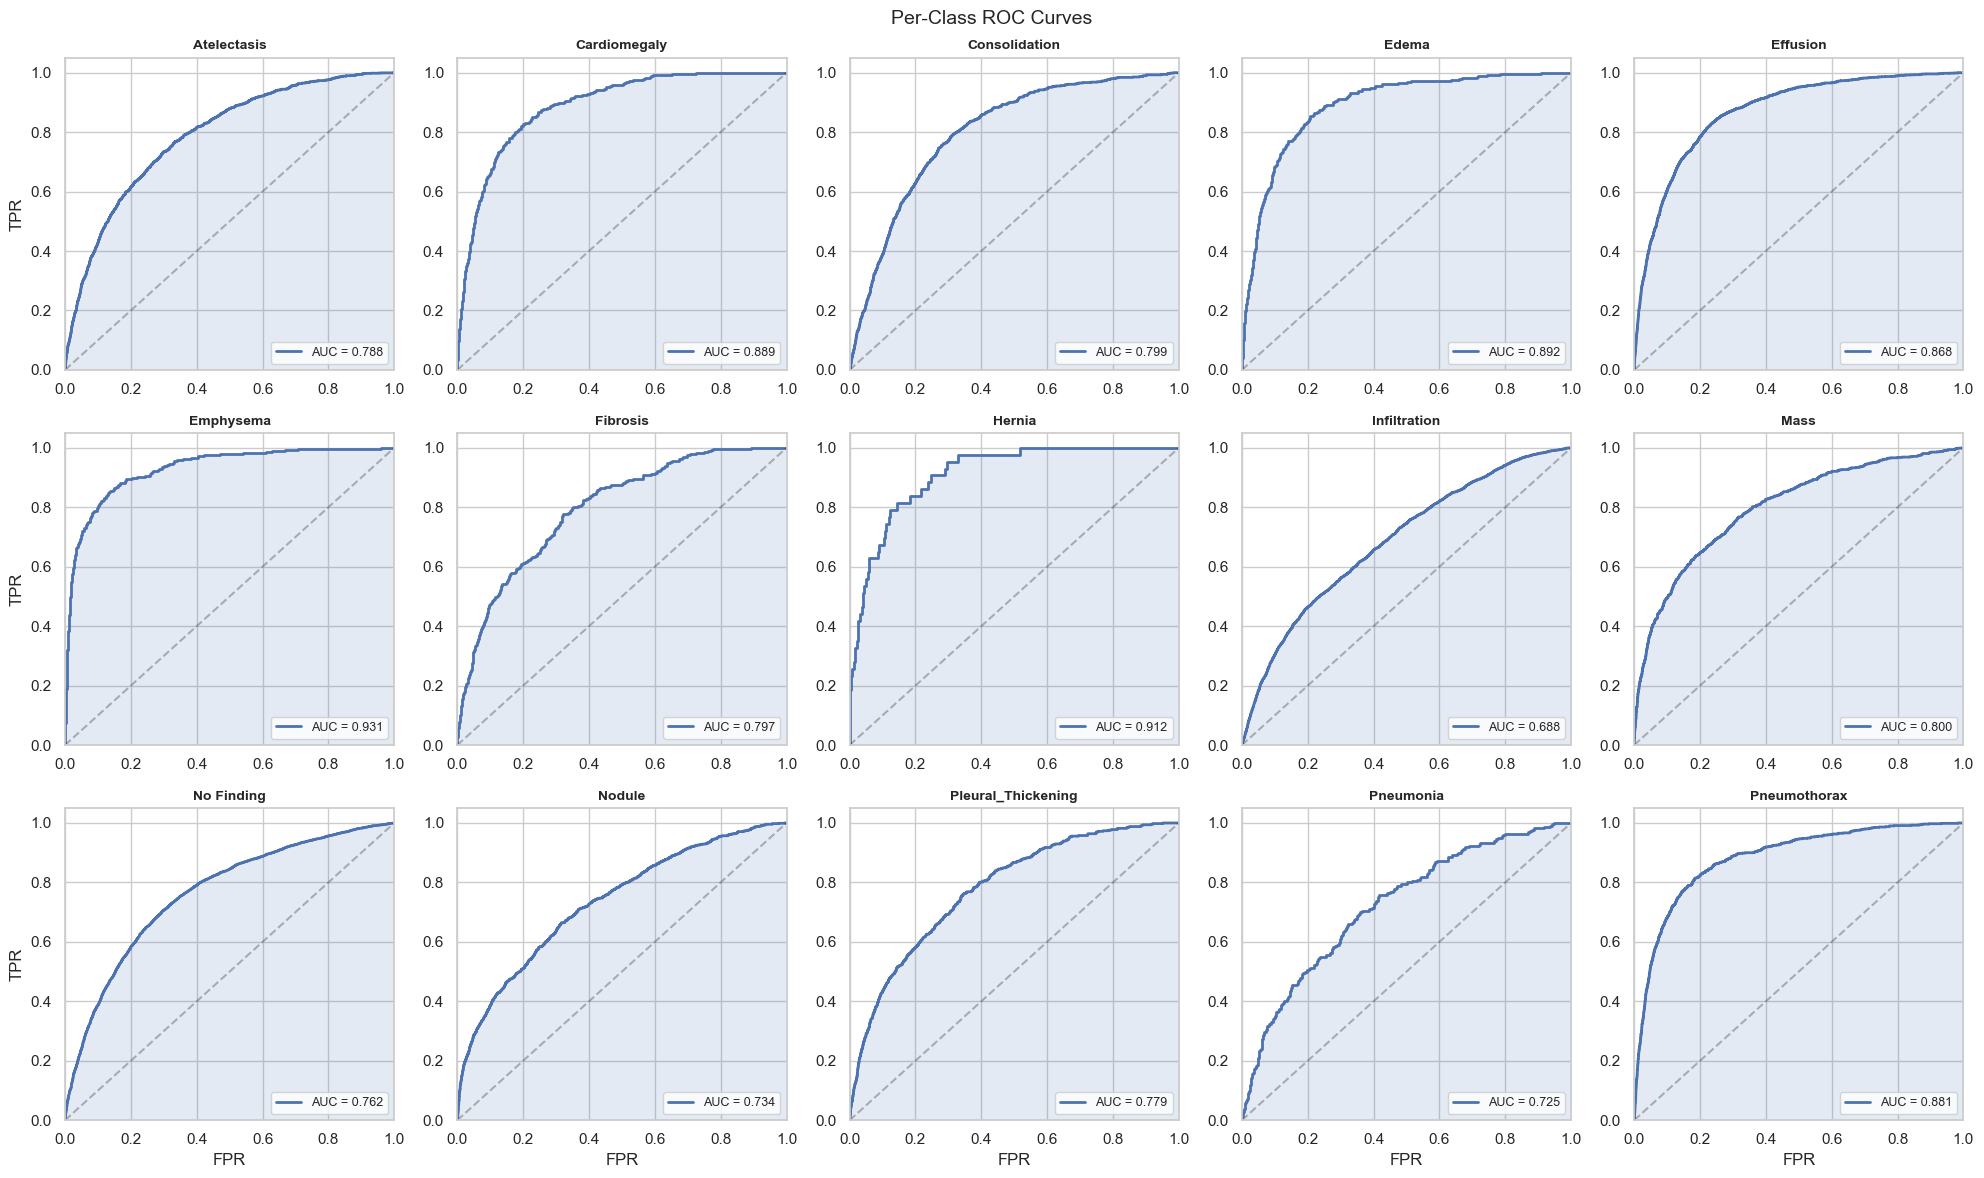

In [8]:
plot_roc_curves(all_labels, all_probs, classes)

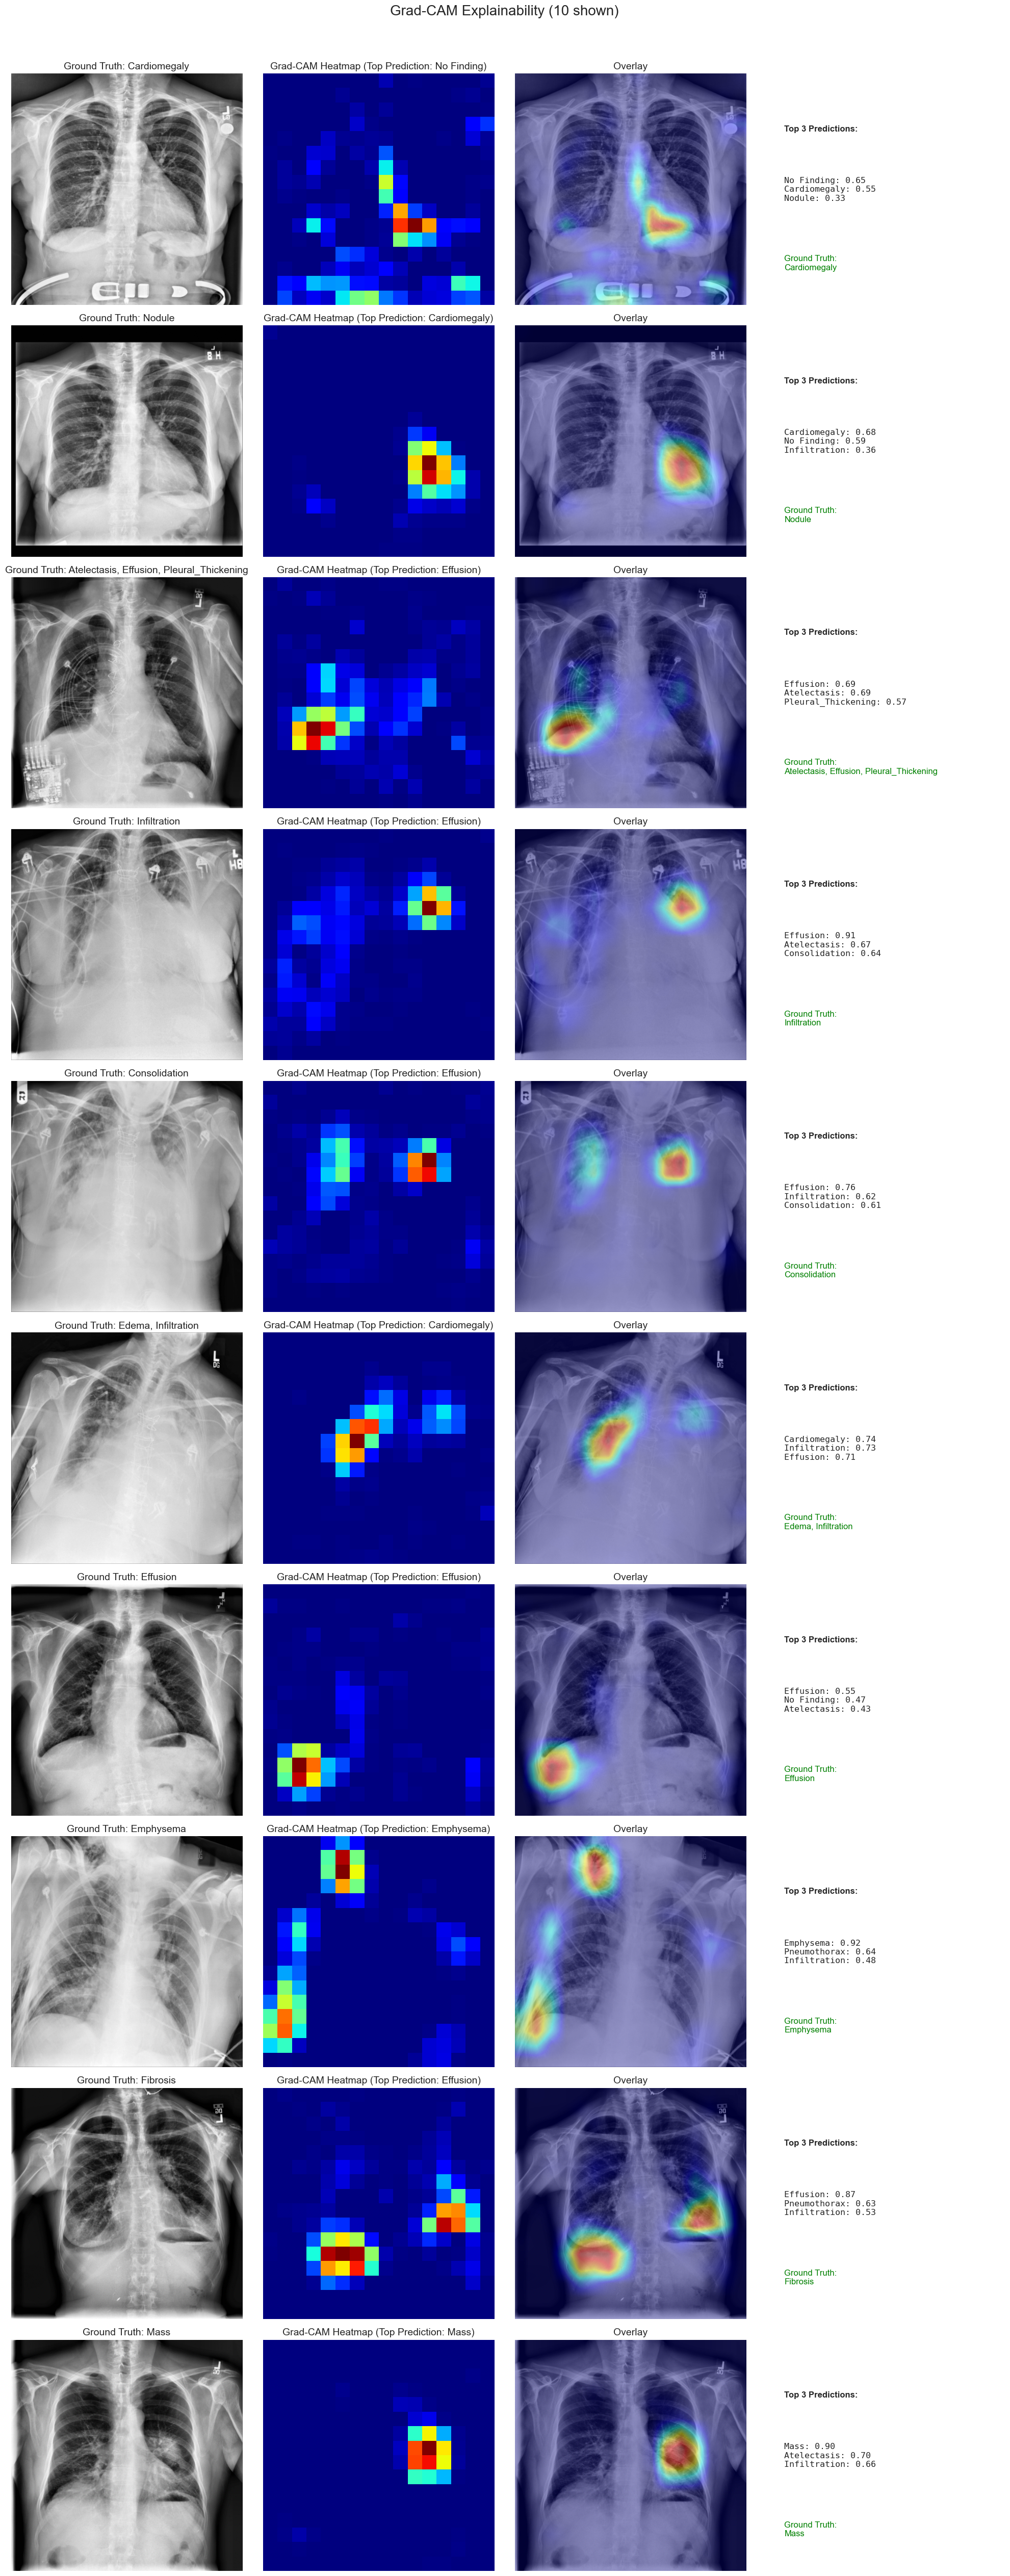

  Pathologies shown: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Infiltration, Mass, Nodule


In [9]:
visualize_gradcam(model, val_ds, train_ds, model.layer4[-1], device, n_samples=10)

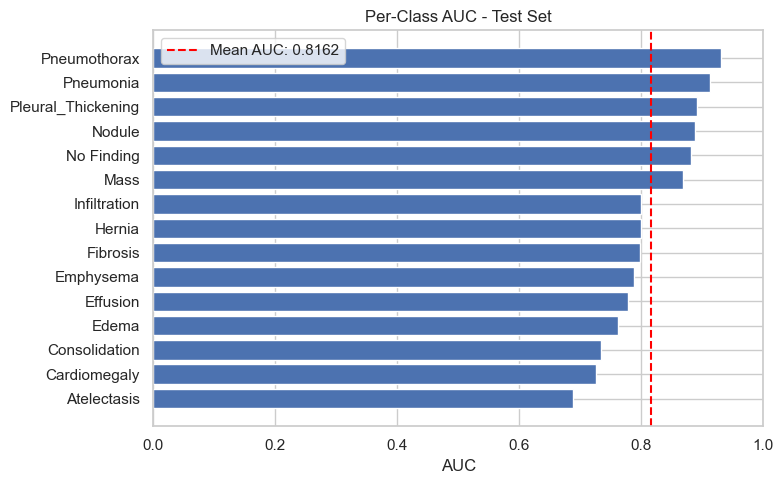

In [10]:
aucs = [test_metrics['auc_per_class'][i] for i in range(num_classes)]
aucs.sort()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(classes, aucs)
ax.axvline(
    x=test_metrics['auc_macro'],
    color='red', linestyle='--',
    label=f"Mean AUC: {test_metrics['auc_macro']:.4f}"
)
ax.set_xlabel('AUC')
ax.set_title('Per-Class AUC - Test Set')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()